In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
def calc_filtered_mid(df, threshold=15):
    """
    Calculates a filtered mid-price, safely ignoring NaN values 
    in the order book data.
    """
    # 1. Extract Arrays
    b_px = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].values
    b_vol = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].values
    a_px = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].values
    a_vol = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].values

    # 2. Safely handle volume NaNs (treat missing volume as 0)
    b_vol_safe = np.nan_to_num(b_vol, nan=0.0)
    a_vol_safe = np.nan_to_num(a_vol, nan=0.0)

    b_mask = b_vol_safe >= threshold
    a_mask = a_vol_safe >= threshold

    # 3. Process Bids
    valid_b_px = np.where(b_mask, b_px, -np.inf)
    # Use nanmax to ignore NaNs in the price columns
    best_b_px_filtered = np.nanmax(valid_b_px, axis=1)
    
    fallback_b_idx = np.argmax(b_vol_safe, axis=1)
    fallback_b_px = b_px[np.arange(len(b_px)), fallback_b_idx]
    
    final_bid = np.where(np.any(b_mask, axis=1), best_b_px_filtered, fallback_b_px)

    # 4. Process Asks
    valid_a_px = np.where(a_mask, a_px, np.inf)
    # Use nanmin to ignore NaNs in the price columns
    best_a_px_filtered = np.nanmin(valid_a_px, axis=1)
    
    fallback_a_idx = np.argmax(a_vol_safe, axis=1)
    fallback_a_px = a_px[np.arange(len(a_px)), fallback_a_idx]
    
    final_ask = np.where(np.any(a_mask, axis=1), best_a_px_filtered, fallback_a_px)

    # 5. Calculate the filtered mid price
    filtered_mid = (final_bid + final_ask) / 2
    filtered_mid = pd.Series(filtered_mid).ffill()

    return filtered_mid

In [3]:
price = pd.read_csv('../data/raw/round_1/prices_round_1_day_-2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean = price_pepper.dropna(subset=price_pepper.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean = price_osmium.dropna(subset=price_osmium.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

In [4]:
price = pd.read_csv('../data/raw/round_1/prices_round_1_day_-1.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper_1 = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium_1 = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean_1 = price_pepper_1.dropna(subset=price_pepper_1.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean_1 = price_osmium_1.dropna(subset=price_osmium_1.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

In [5]:
price = pd.read_csv('../data/raw/round_1/prices_round_1_day_0.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper_2 = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium_2 = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean_2 = price_pepper_2.dropna(subset=price_pepper_2.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean_2 = price_osmium_2.dropna(subset=price_osmium_2.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

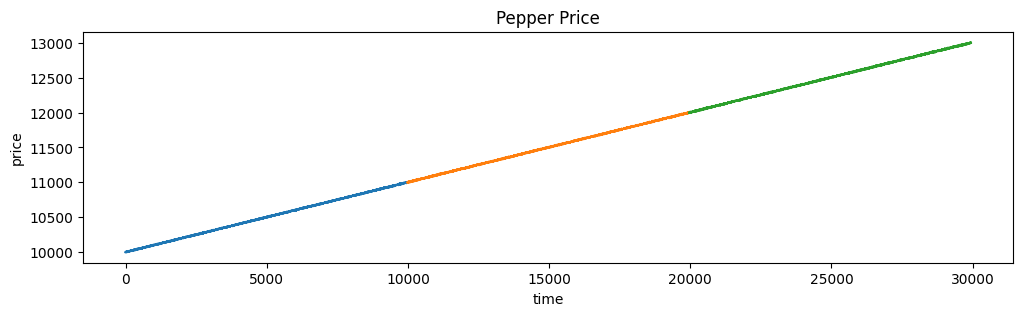

In [6]:
plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(price_pepper_clean)), price_pepper_clean['mid_price'])
plt.plot(np.arange(len(price_pepper_clean), len(price_pepper_clean) + len(price_pepper_clean_1)), price_pepper_clean_1['mid_price'])
plt.plot(np.arange(len(price_pepper_clean) + len(price_pepper_clean_1), len(price_pepper_clean) + len(price_pepper_clean_1) + len(price_pepper_clean_2)), price_pepper_clean_2['mid_price'])
plt.title('Pepper Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

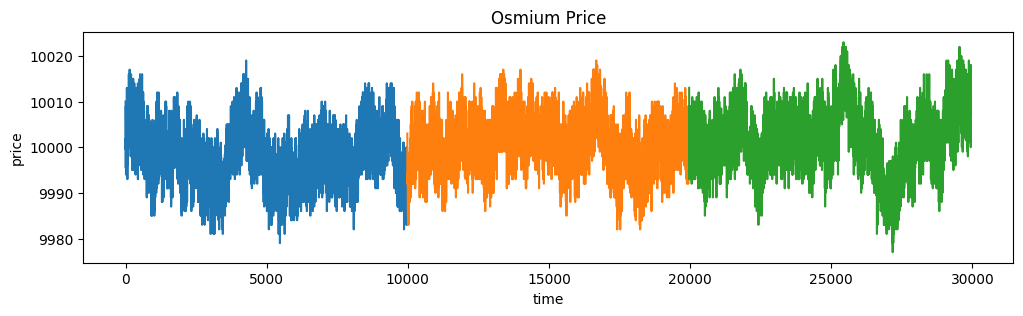

In [7]:
plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(price_osmium_clean)), price_osmium_clean['mid_price'])
plt.plot(np.arange(len(price_osmium_clean), len(price_osmium_clean) + len(price_osmium_clean_1)), price_osmium_clean_1['mid_price'])
plt.plot(np.arange(len(price_osmium_clean) + len(price_osmium_clean_1), len(price_osmium_clean) + len(price_osmium_clean_1) + len(price_osmium_clean_2)), price_osmium_clean_2['mid_price'])
plt.title('Osmium Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

# INTARIAN_PEPPER_ROOT

In [17]:
price_pepper_clean.head()

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
0,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5
1,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5
2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5
3,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0
4,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0


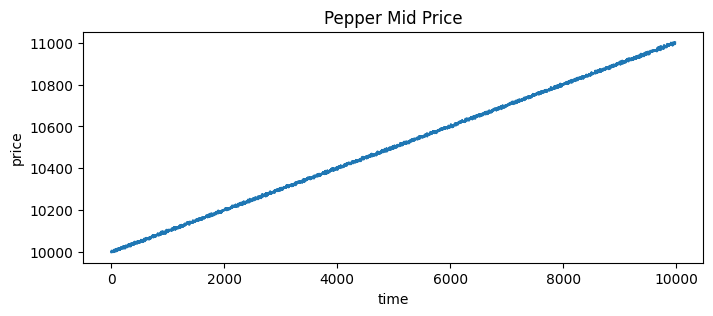

In [23]:
plt.figure(figsize=(8, 3))
plt.plot(price_pepper_clean['mid_price'])
plt.title('Pepper Mid Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

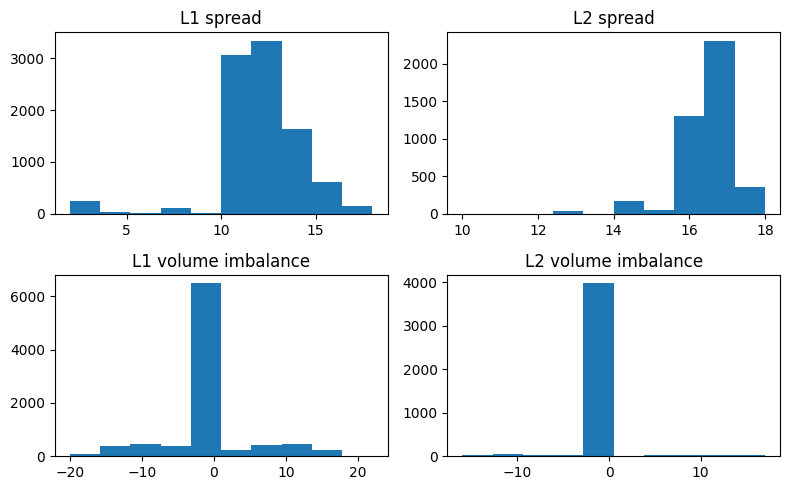

In [62]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_pepper_clean['ask_price_1'] - price_pepper_clean['bid_price_1'])
ax[0, 1].hist(price_pepper_clean['ask_price_2'] - price_pepper_clean['bid_price_2'])
ax[1, 0].hist(price_pepper_clean['ask_volume_1'] - price_pepper_clean['bid_volume_1'])
ax[1, 1].hist(price_pepper_clean['ask_volume_2'] - price_pepper_clean['bid_volume_2'])
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

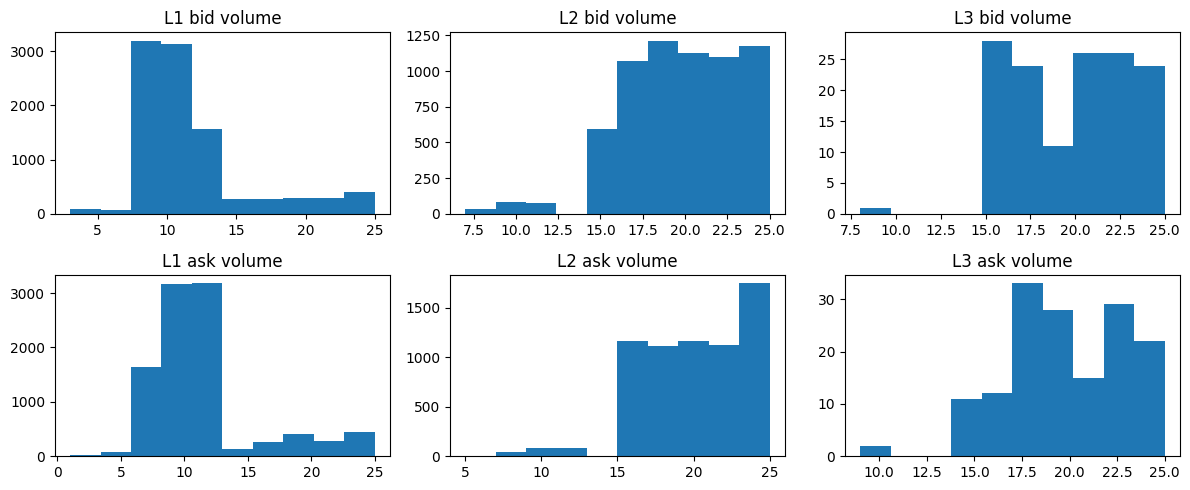

In [58]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_pepper_clean['bid_volume_1'])
ax[0, 1].hist(price_pepper_clean['bid_volume_2'])
ax[0, 2].hist(price_pepper_clean['bid_volume_3'])
ax[1, 0].hist(price_pepper_clean['ask_volume_1'])
ax[1, 1].hist(price_pepper_clean['ask_volume_2'])
ax[1, 2].hist(price_pepper_clean['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [65]:
price_pepper_clean = price_pepper_clean.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))

In [66]:
price_pepper_clean['filtered_mid']

0       10000.0
1       10000.0
2       10001.5
3       10001.5
4       10000.0
         ...   
9979    10999.5
9980    11000.0
9981    10999.5
9982    10999.5
9983    11001.5
Name: filtered_mid, Length: 9984, dtype: float64

In [67]:
params = np.polyfit(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['mid_price'], deg=1)

In [68]:
params

array([1.00440636e-01, 1.00000587e+04])

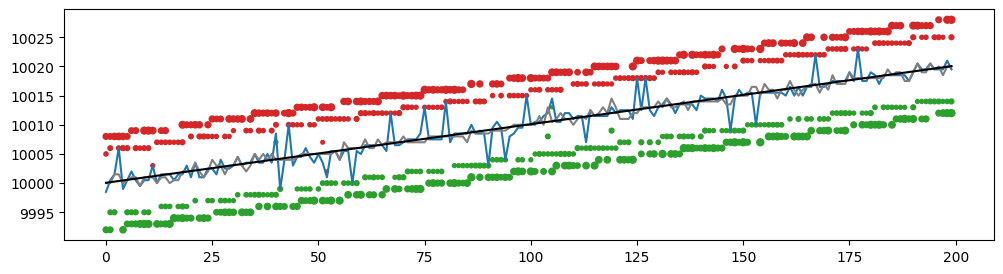

In [69]:
plt.figure(figsize=(12, 3))
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['bid_price_1'], s=price_pepper_clean.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['bid_price_2'], s=price_pepper_clean.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['bid_price_3'], s=price_pepper_clean.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['ask_price_1'], s=price_pepper_clean.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['ask_price_2'], s=price_pepper_clean.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['ask_price_3'], s=price_pepper_clean.iloc[:200]['ask_volume_3'], c='tab:red')
plt.plot(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['mid_price'])
plt.plot(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['filtered_mid'], c='gray')
plt.plot(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['timestamp']//100 * params[0] + params[1], c='k')
plt.show()

# ASH_COATED_OSMIUM

In [22]:
price_osmium_clean.head()

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0
1,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0
2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0
3,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0
4,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0


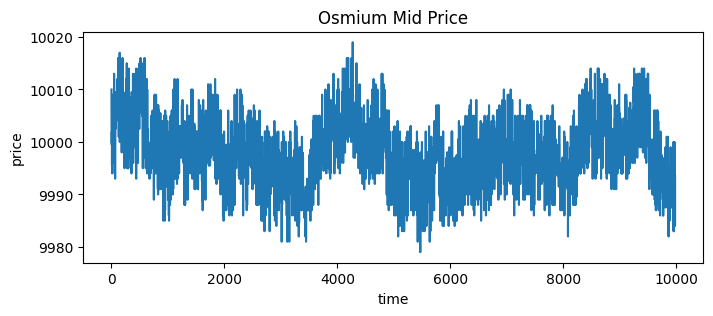

In [24]:
plt.figure(figsize=(8, 3))
plt.plot(price_osmium_clean['mid_price'])
plt.title('Osmium Mid Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

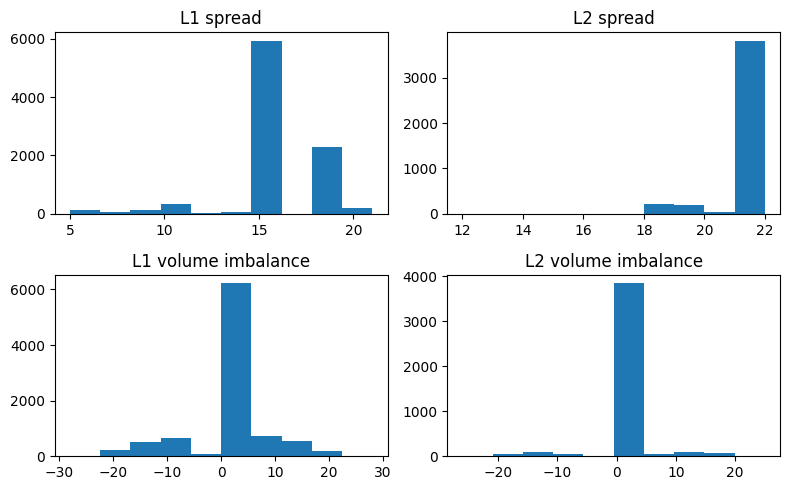

In [63]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_osmium_clean['ask_price_1'] - price_osmium_clean['bid_price_1'])
ax[0, 1].hist(price_osmium_clean['ask_price_2'] - price_osmium_clean['bid_price_2'])
ax[1, 0].hist(price_osmium_clean['ask_volume_1'] - price_osmium_clean['bid_volume_1'])
ax[1, 1].hist(price_osmium_clean['ask_volume_2'] - price_osmium_clean['bid_volume_2'])
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

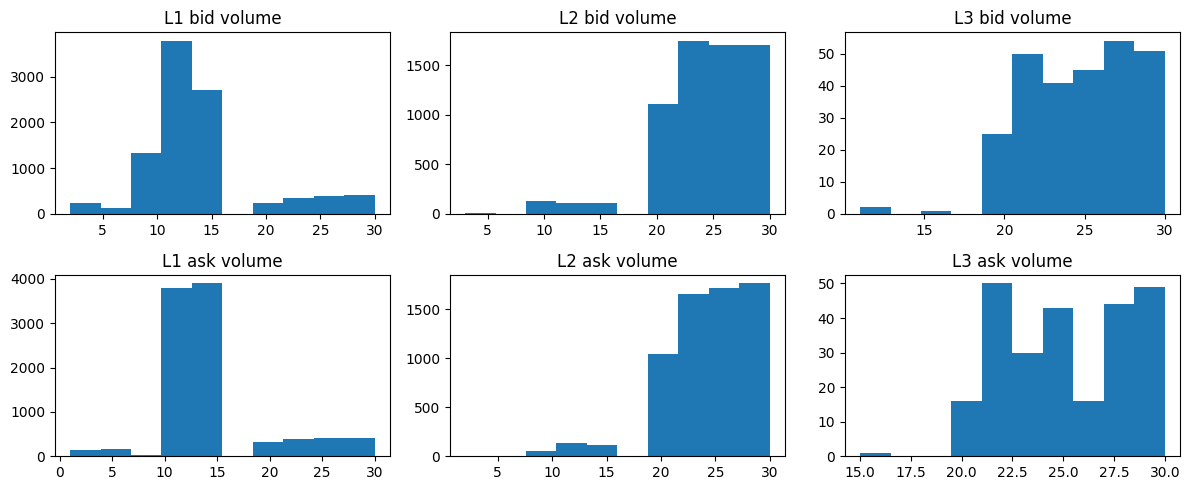

In [64]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_osmium_clean['bid_volume_1'])
ax[0, 1].hist(price_osmium_clean['bid_volume_2'])
ax[0, 2].hist(price_osmium_clean['bid_volume_3'])
ax[1, 0].hist(price_osmium_clean['ask_volume_1'])
ax[1, 1].hist(price_osmium_clean['ask_volume_2'])
ax[1, 2].hist(price_osmium_clean['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [93]:
# price_osmium_clean = price_osmium_clean.assign(filtered_mid=(price_osmium_clean['bid_price_2'] + price_osmium_clean['ask_price_2']) / 2)
# price_osmium_clean['filtered_mid'] = price_osmium_clean['filtered_mid'].ffill()

In [77]:
price_pepper_clean = price_pepper_clean.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))

In [78]:
price_osmium_clean['filtered_mid']

0           NaN
1       10000.0
2       10000.0
3        9999.5
4       10000.0
         ...   
9977     9992.5
9978     9992.0
9979     9992.5
9980     9992.5
9981     9993.5
Name: filtered_mid, Length: 9982, dtype: float64

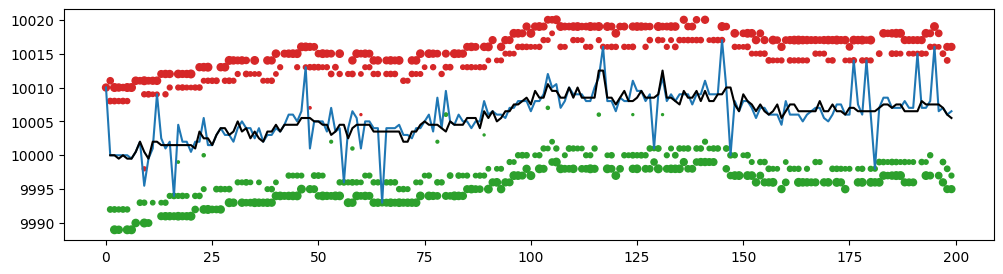

In [79]:
plt.figure(figsize=(12, 3))
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['bid_price_1'], s=price_osmium_clean.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['bid_price_2'], s=price_osmium_clean.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['bid_price_3'], s=price_osmium_clean.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['ask_price_1'], s=price_osmium_clean.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['ask_price_2'], s=price_osmium_clean.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['ask_price_3'], s=price_osmium_clean.iloc[:200]['ask_volume_3'], c='tab:red')
plt.plot(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['mid_price'])
plt.plot(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['filtered_mid'], c='k')
plt.show()

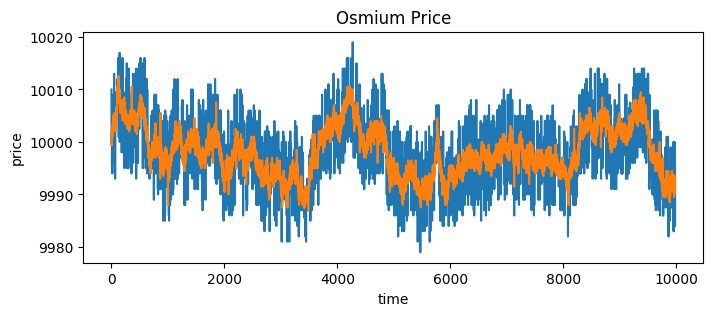

In [80]:
plt.figure(figsize=(8, 3))
plt.plot(price_osmium_clean['mid_price'])
plt.plot(price_osmium_clean['filtered_mid'])
plt.title('Osmium Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

# TOMATOES Forcasting

In [53]:
train_logr = np.log(price_tomatoes['filtered_mid']).diff().dropna()
test_logr = np.log(price_tomatoes_test['filtered_mid']).diff().dropna()

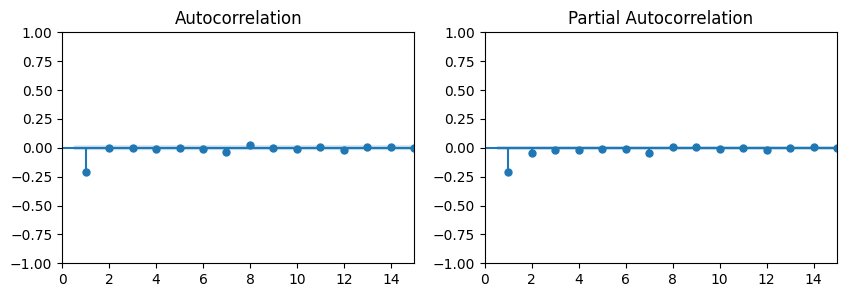

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(logr_tomatoes, ax=ax[0], zero=False)
plot_pacf(logr_tomatoes, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [57]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

       lb_stat     lb_pvalue
10  461.694601  6.682467e-93
Reject null hypothesis: data is not white noise.


In [71]:
true = test_logr[1:].to_numpy()

In [72]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.00020966653184623836


In [85]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.21, b = 0.0
AR(1) RMSE: 0.00013119439974993094
